# Weather Anomaly — Exploration
EDA notebook: inspect raw data, prototype z-score labeling, and select features for the model.

In [10]:
import sys
import os

# Make src/ importable from notebooks/
sys.path.insert(0, os.path.abspath(".."))

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.fetch import fetch_weather, load_weather
from src.utils.config import ANOMALY_THRESHOLD_STD, DAILY_VARS, HOURLY_VARS

%matplotlib inline
sns.set_theme(style="darkgrid")

## 1. Load Data
Use `load_weather()` if CSVs already exist, otherwise fetch from the API.

In [12]:
try:
    hourly_df, daily_df = load_weather()
    print("Loaded from disk.")
except FileNotFoundError:
    print("Fetching from API...")
    hourly_df, daily_df = fetch_weather()
    print("Done.")

print(f"Hourly: {hourly_df.shape}  |  Daily: {daily_df.shape}")
print(f"Date range: {hourly_df.index.min()} → {hourly_df.index.max()}")

Fetching from API...
Done.
Hourly: (143280, 33)  |  Daily: (5970, 16)
Date range: 2010-01-01 06:00:00+00:00 → 2026-05-07 05:00:00+00:00


## 2. Inspect Shape, Types, and Nulls

In [13]:
hourly_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 143280 entries, 2010-01-01 06:00:00+00:00 to 2026-05-07 05:00:00+00:00
Freq: h
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   temperature_2m              143280 non-null  float32
 1   apparent_temperature        143280 non-null  float32
 2   dew_point_2m                143280 non-null  float32
 3   relative_humidity_2m        143280 non-null  float32
 4   precipitation               143280 non-null  float32
 5   rain                        143280 non-null  float32
 6   showers                     143280 non-null  float32
 7   snowfall                    143280 non-null  float32
 8   snow_depth                  143280 non-null  float32
 9   wind_speed_10m              143280 non-null  float32
 10  wind_speed_80m              0 non-null       float32
 11  wind_gusts_10m              143280 non-null  float32
 12  wind_direction_10m          1

In [14]:
daily_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5970 entries, 2010-01-01 06:00:00+00:00 to 2026-05-06 06:00:00+00:00
Freq: 24h
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temperature_2m_max             5970 non-null   float32
 1   temperature_2m_min             5970 non-null   float32
 2   temperature_2m_mean            5970 non-null   float32
 3   apparent_temperature_max       5970 non-null   float32
 4   apparent_temperature_min       5970 non-null   float32
 5   precipitation_sum              5970 non-null   float32
 6   rain_sum                       5970 non-null   float32
 7   snowfall_sum                   5970 non-null   float32
 8   precipitation_hours            5970 non-null   float32
 9   precipitation_probability_max  0 non-null      float32
 10  wind_speed_10m_max             5970 non-null   float32
 11  wind_gusts_10m_max             5970 non-null   float32
 12  w

In [15]:
hourly_nulls = hourly_df.isnull().sum()
daily_nulls  = daily_df.isnull().sum()

print("=== Hourly nulls ===")
print(hourly_nulls[hourly_nulls > 0].to_string() or "None")
print("\n=== Daily nulls ===")
print(daily_nulls[daily_nulls > 0].to_string() or "None")

=== Hourly nulls ===
wind_speed_80m                143280
cape                          143280
freezing_level_height         143280
visibility                    143280
temperature_850hPa            143280
relative_humidity_850hPa      143280
wind_speed_850hPa             143280
geopotential_height_850hPa    143280
temperature_500hPa            143280
wind_speed_500hPa             143280
geopotential_height_500hPa    143280
wind_speed_300hPa             143280
geopotential_height_300hPa    143280

=== Daily nulls ===
precipitation_probability_max    5970
uv_index_max                     5970


In [16]:
hourly_df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,143280.0,9.626460,11.941909,-36.450001,0.369500,9.700000,18.519501,38.700001
apparent_temperature,143280.0,6.608021,13.055051,-42.879871,-3.657887,6.547629,16.883688,36.848549
dew_point_2m,143280.0,-1.398846,8.654848,-40.000000,-7.500000,-1.750000,5.550000,20.650000
relative_humidity_2m,143280.0,53.235279,23.393629,2.634216,33.821393,54.174294,72.079010,100.000000
precipitation,143280.0,0.051969,0.276712,0.000000,0.000000,0.000000,0.000000,11.500000
rain,143280.0,0.034516,0.241618,0.000000,0.000000,0.000000,0.000000,11.500000
showers,143280.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
snowfall,143280.0,0.012499,0.087410,0.000000,0.000000,0.000000,0.000000,3.500000
snow_depth,143280.0,0.021243,0.044791,0.000000,0.000000,0.000000,0.020000,0.310000
wind_speed_10m,143280.0,8.389166,4.855985,0.000000,5.116561,7.579261,10.630672,75.550262


In [17]:
daily_df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_max,5970.0,17.573151,11.117489,-19.500000,8.977125,18.119501,27.150000,38.700001
temperature_2m_min,5970.0,2.444139,10.082254,-36.450001,-4.800000,2.400000,11.450000,22.350000
temperature_2m_mean,5970.0,9.626460,10.594833,-23.424246,1.100042,9.726041,19.106290,29.152084
apparent_temperature_max,5970.0,14.894098,12.276814,-24.106775,4.999072,15.230823,25.847898,36.848549
apparent_temperature_min,5970.0,-0.828488,11.416566,-42.879871,-9.238502,-1.270900,9.453125,21.564274
precipitation_sum,5970.0,1.247253,3.536419,0.000000,0.000000,0.000000,0.600000,49.799999
rain_sum,5970.0,0.828375,2.892505,0.000000,0.000000,0.000000,0.200000,49.799999
snowfall_sum,5970.0,0.299968,1.296136,0.000000,0.000000,0.000000,0.000000,23.099998
precipitation_hours,5970.0,2.166834,4.325387,0.000000,0.000000,0.000000,2.000000,24.000000
precipitation_probability_max,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Time Series Plots
Visual sanity check on the primary signals.

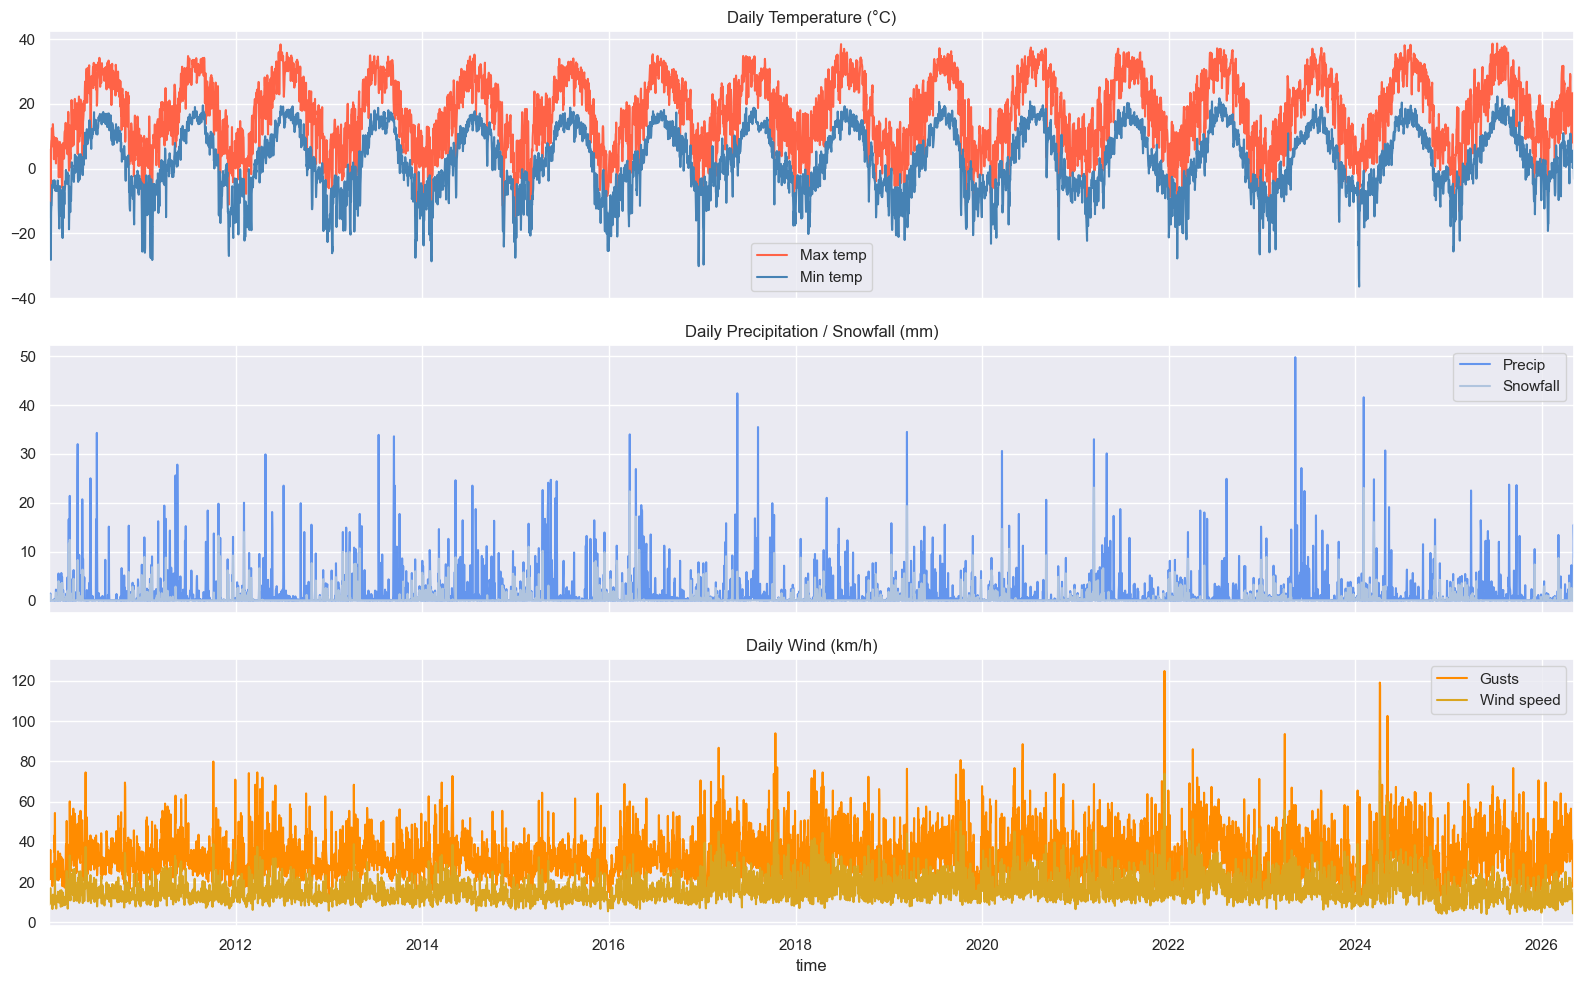

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

daily_df["temperature_2m_max"].plot(ax=axes[0], label="Max temp", color="tomato")
daily_df["temperature_2m_min"].plot(ax=axes[0], label="Min temp", color="steelblue")
axes[0].set_title("Daily Temperature (°C)")
axes[0].legend()

daily_df["precipitation_sum"].plot(ax=axes[1], label="Precip", color="cornflowerblue")
daily_df["snowfall_sum"].plot(ax=axes[1], label="Snowfall", color="lightsteelblue")
axes[1].set_title("Daily Precipitation / Snowfall (mm)")
axes[1].legend()

daily_df["wind_gusts_10m_max"].plot(ax=axes[2], label="Gusts", color="darkorange")
daily_df["wind_speed_10m_max"].plot(ax=axes[2], label="Wind speed", color="goldenrod")
axes[2].set_title("Daily Wind (km/h)")
axes[2].legend()

plt.tight_layout()

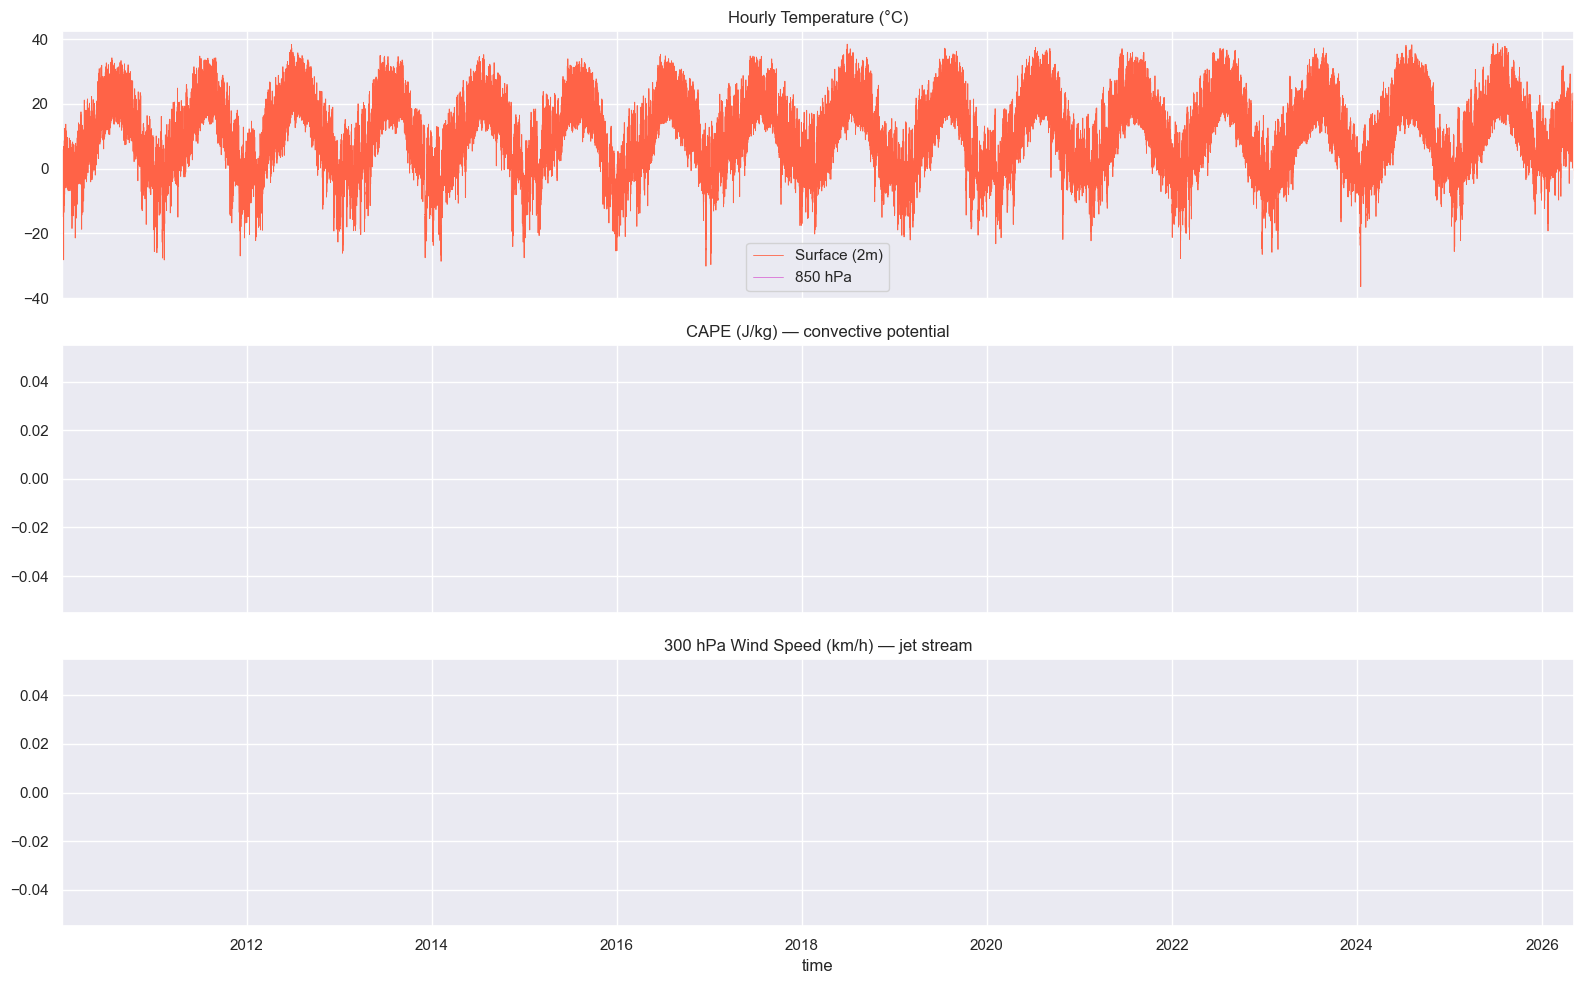

In [19]:
# Hourly temperature + upper-air signals
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

hourly_df["temperature_2m"].plot(ax=axes[0], label="Surface (2m)", color="tomato", lw=0.6)
hourly_df["temperature_850hPa"].plot(ax=axes[0], label="850 hPa", color="orchid", lw=0.6)
axes[0].set_title("Hourly Temperature (°C)")
axes[0].legend()

hourly_df["cape"].plot(ax=axes[1], color="firebrick", lw=0.6)
axes[1].set_title("CAPE (J/kg) — convective potential")

hourly_df["wind_speed_300hPa"].plot(ax=axes[2], color="slateblue", lw=0.6)
axes[2].set_title("300 hPa Wind Speed (km/h) — jet stream")

plt.tight_layout()

## 4. Z-Score Anomaly Labeling (Prototype)
Type 1 anomaly: deviation from the seasonal historical mean for each calendar day.

Logic to port into `src/data/injest.py` once validated here.

In [20]:
def compute_seasonal_zscore(series: pd.Series, window_days: int = 15) -> pd.Series:
    """Rolling seasonal z-score: compare each day to same day-of-year ± window across all years."""
    doy = series.index.day_of_year
    z = pd.Series(index=series.index, dtype=float)
    for d in range(1, 367):
        mask = (doy >= d - window_days) & (doy <= d + window_days)
        ref = series[mask]
        mu, sigma = ref.mean(), ref.std()
        target = series[doy == d]
        if sigma > 0:
            z[doy == d] = (target - mu) / sigma
    return z


daily_df["temp_max_zscore"] = compute_seasonal_zscore(daily_df["temperature_2m_max"])
daily_df["is_temp_anomaly"] = daily_df["temp_max_zscore"].abs() > ANOMALY_THRESHOLD_STD

n_anomalies = daily_df["is_temp_anomaly"].sum()
pct = 100 * n_anomalies / len(daily_df)
print(f"Temperature anomalies flagged: {n_anomalies} / {len(daily_df)} days ({pct:.1f}%)")

Temperature anomalies flagged: 209 / 5970 days (3.5%)


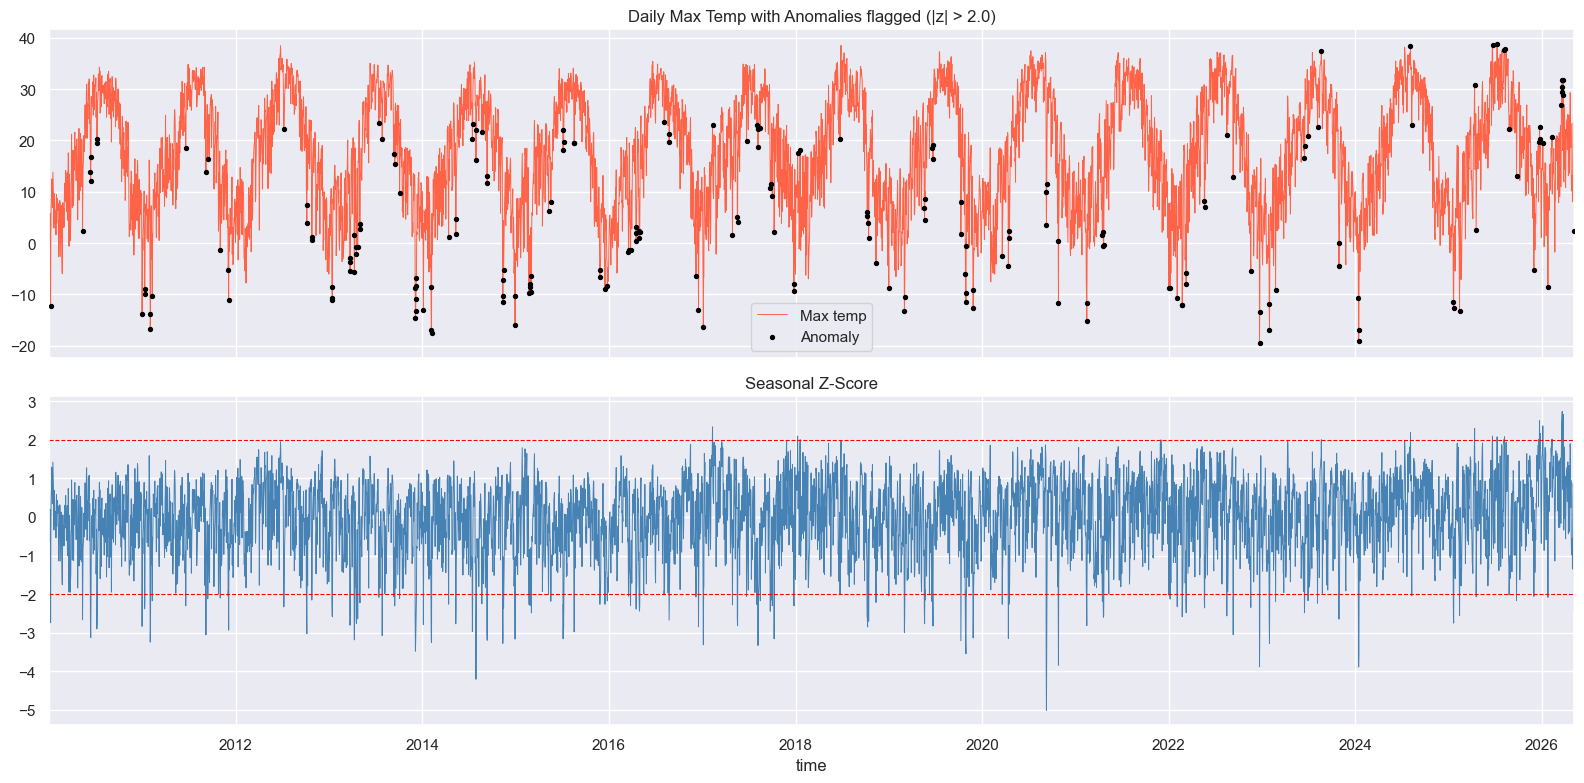

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

daily_df["temperature_2m_max"].plot(ax=axes[0], color="tomato", lw=0.7, label="Max temp")
anomaly_pts = daily_df.loc[daily_df["is_temp_anomaly"], "temperature_2m_max"]
axes[0].scatter(anomaly_pts.index, anomaly_pts.values, color="black", s=8, zorder=5, label="Anomaly")
axes[0].set_title(f"Daily Max Temp with Anomalies flagged (|z| > {ANOMALY_THRESHOLD_STD})")
axes[0].legend()

daily_df["temp_max_zscore"].plot(ax=axes[1], color="steelblue", lw=0.7)
axes[1].axhline(ANOMALY_THRESHOLD_STD, color="red", ls="--", lw=0.8)
axes[1].axhline(-ANOMALY_THRESHOLD_STD, color="red", ls="--", lw=0.8)
axes[1].set_title("Seasonal Z-Score")

plt.tight_layout()

## 5. Correlation Matrix — Daily Variables
Use this to identify redundant features and guide variable selection for the model.

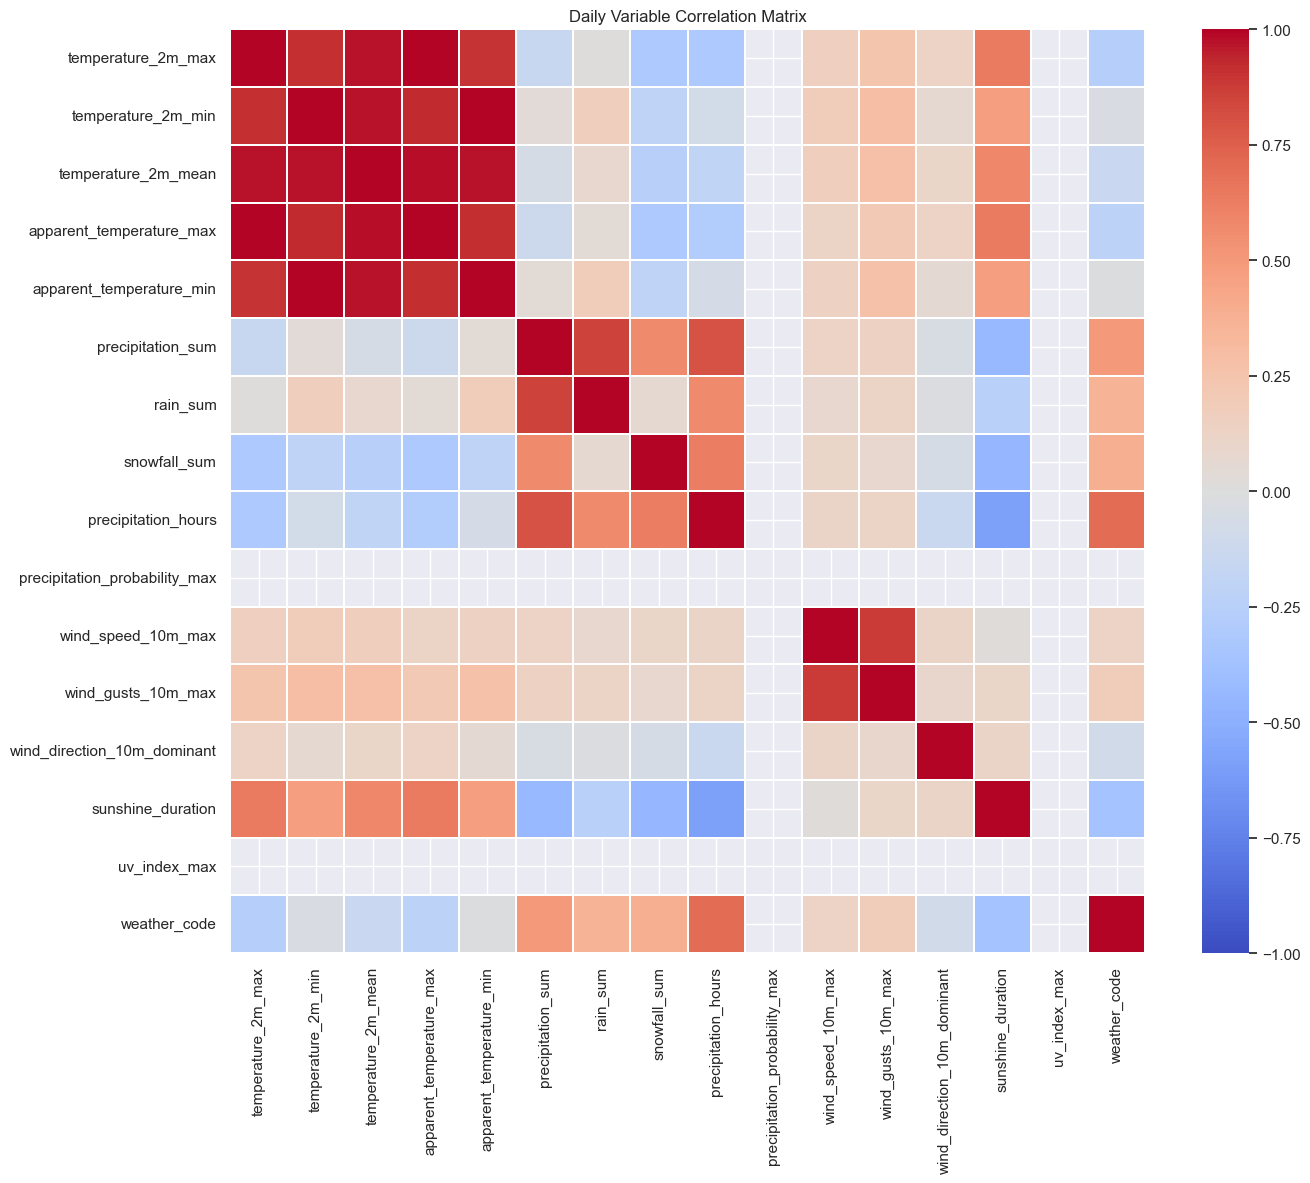

In [22]:
numeric_daily = daily_df[DAILY_VARS].select_dtypes(include="number")
corr = numeric_daily.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
)
ax.set_title("Daily Variable Correlation Matrix")
plt.tight_layout()

In [23]:
# Pairs with |r| > 0.85 — candidates for dropping one of the two
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr[high_corr > 0.85]

temperature_2m_min        apparent_temperature_min    0.996824
temperature_2m_max        apparent_temperature_max    0.993810
temperature_2m_mean       apparent_temperature_max    0.977895
temperature_2m_max        temperature_2m_mean         0.974702
temperature_2m_min        temperature_2m_mean         0.974529
temperature_2m_mean       apparent_temperature_min    0.969699
temperature_2m_min        apparent_temperature_max    0.923718
apparent_temperature_max  apparent_temperature_min    0.920413
temperature_2m_max        temperature_2m_min          0.913863
                          apparent_temperature_min    0.906102
wind_speed_10m_max        wind_gusts_10m_max          0.877307
precipitation_sum         rain_sum                    0.854842
dtype: float64

## 6. Correlation Matrix — Hourly Variables

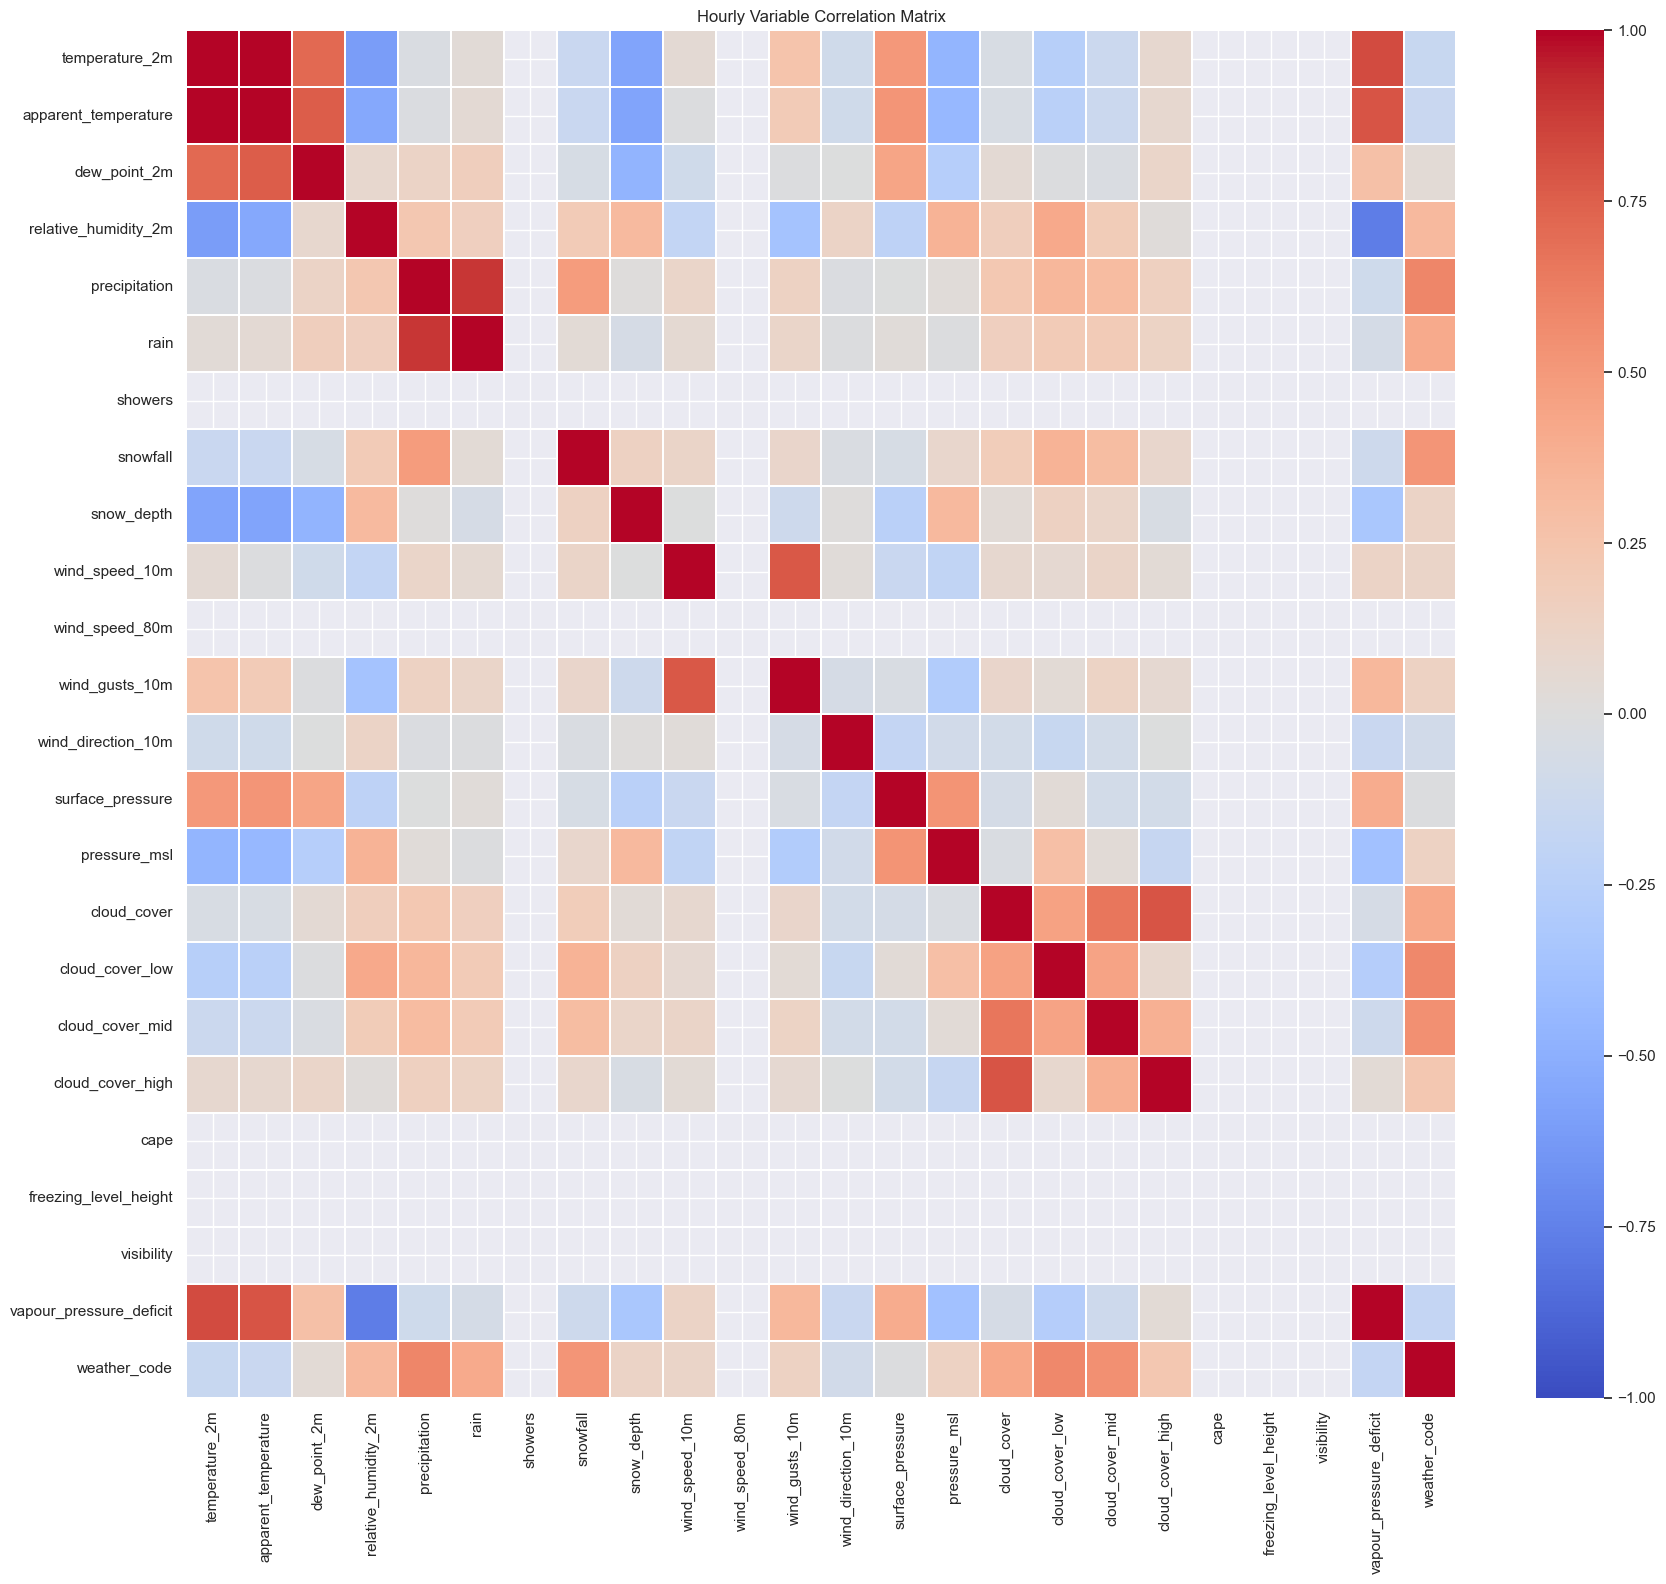

In [24]:
numeric_hourly = hourly_df[HOURLY_VARS].select_dtypes(include="number")
corr_h = numeric_hourly.corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    corr_h,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
)
ax.set_title("Hourly Variable Correlation Matrix")
plt.tight_layout()

## 7. Scratch Pad
Use cells below to iterate on cleaning logic, feature engineering, or labeling before porting to `injest.py`.